## Finne amplitude-nivå på inputstrøm 
Målet her er å finne amplituden til input-strømmen (AC-generator) ved et membranpotensial på 0.16 mV. Dette gjøres ved hjelp av transferfunksjonen definert nedenfor. Bruker og får en spesifikk verdi for en gitt frekvens. 

In [4]:
%matplotlib inline
import numpy as np
from numpy import random
import random
import math
import matplotlib.pyplot as plt
from operator import add
import itertools
import nest

import os
import sys
Path = os.getcwd()
sys.path.append(Path)
from utilities1 import *
from build_simulation import *

In [3]:
def find_I(V_target_si, f, tau_si=10e-3, R_si=100e6, E_m_si=-60e-3):
    a_si = (-E_m_si+V_target_si) * math.sqrt(1 + (2*math.pi*f*tau_si)**2) / R_si
    a = a_si/(1e-12)
    return a

In [3]:
I = find_I(-51e-3, 10)
print(I)

106.29088308012572


In [3]:
# Definer parametere
tau_si = 10e-3  # 10 ms
R_si = 100e6  # 100 MΩ
I_amp_12 = 75  # 10 pA funnet for 12 Hz

# Transferfunksjonen for å finne ny strøm ved 1012 Hz
scaling_factor = math.sqrt(1 + (2 * math.pi * 100 * tau_si)**2) / math.sqrt(1 + (2 * math.pi * 10 * tau_si)**2)
I_amp_1012 = I_amp_12 * scaling_factor

print(f"Forventet I_amp ved 100 Hz: {I_amp_1012:.2f} pA")

Forventet I_amp ved 100 Hz: 404.04 pA


In [11]:
def find_input_amplitude(f, V_target, tau_m, R_si):
    tau_si = tau_m*1e-3
    V_target_si = V_target * 1e-3  # korrekt konvertering til Volt
    I_amp_si = V_target_si * np.sqrt(1 + (2 * np.pi * f * tau_si)**2) / R_si
    I_amp_pA = I_amp_si / 1e-12  # konverter til pA
    print(f"Amplitude når f={f}Hz og V_target={V_target}mV: I_amp={I_amp_pA:.2f} pA")
    return I_amp_pA


In [5]:
find_input_amplitude(f = 10, V_target = 4, tau_m=10, R_si=100*1e6)

Amplitude når f=10Hz og V_target=0.16mV: I_amp=1.89 pA


1.889615699202235

## A.
Finne endringen i membranpotensial ved f utifra I_amp(f1) og dermed kan vi finne I_amp(f2)
(Uke 10)

In [5]:
def find_V_from_I(sim_time=5000, noisy=False, 
                  second_sine=False,tau_m=10,
                 a=100, sd=250, f=12, beat=2,
                E_m=-60, V_th=0, bin_size=1, seed=np.random.randint(0,1e+6)):
    
    results = build_simulation(sim_time=sim_time, noisy=noisy, second_sine=second_sine, tau_m=tau_m, resolution=0.1,
                                        f1=f, beat=beat, a=a, SD=sd, seed=seed,V_thresh=V_th)  
       
            
    spike_times = results["spike_times"]
    Vm = results["Vm"]
    V_th = results["V_th"]
    sim_time = results["sim_time"]
    times = results["times"]
    times = times[-1000:]
    Vm = Vm[-1000:]
    plt.plot(times, Vm)
    plt.xlabel("Tid (ms)")
    plt.ylabel("Membranpotensial (mV)")
    plt.legend()
    plt.show()
    
    print("Max endring i membranpotensial:", np.abs(np.max(Vm)-E_m))
    Vm_amplitude = (np.max(Vm) - np.min(Vm)) / 2
    print(f"Simulert Vm amplitude: {Vm_amplitude:.4f} mV")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


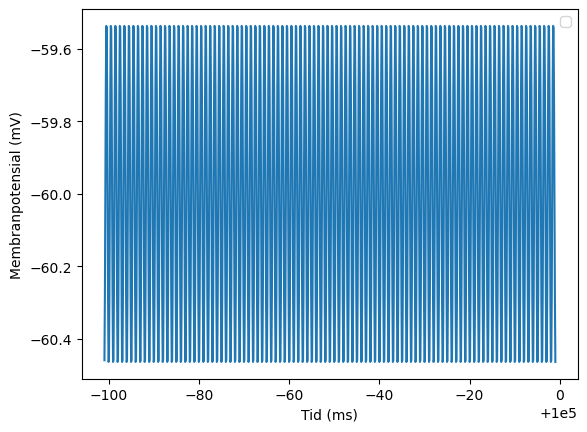

Max endring i membranpotensial: 0.4638470689608809
Simulert Vm amplitude: 0.4638 mV


In [7]:
"""22/9"""
find_V_from_I(sim_time=100e3, noisy=False, 
                 second_sine=False,
                 a=300, sd=0, f=1000, tau_m=10,
                 E_m=-60, V_th=1e6, bin_size=0.25, seed=42)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


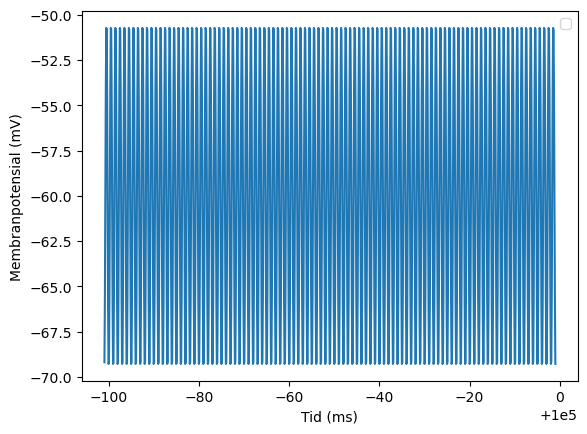

Max endring i membranpotensial: 9.276941379217646
Simulert Vm amplitude: 9.2769 mV


In [8]:
"""22/9"""
find_V_from_I(sim_time=100e3, noisy=False, 
                 second_sine=False,
                 a=6000, sd=0, f=1000, tau_m=10,
                 E_m=-60, V_th=1e6, bin_size=0.25, seed=42)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



May 09 19:07:29 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.


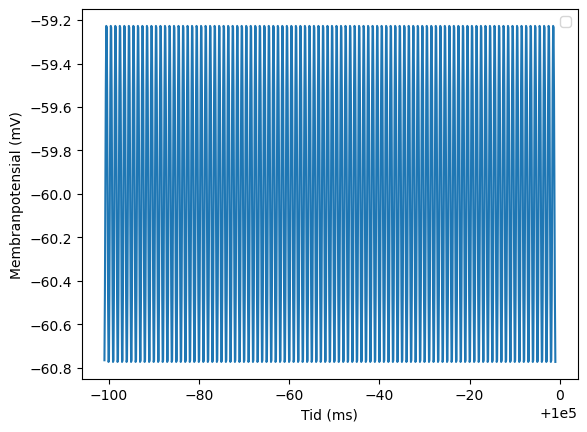

Max endring i membranpotensial: 0.7730784482681372
Simulert Vm amplitude: 0.7731 mV


In [5]:
find_V_from_I(sim_time=100000, noisy=False, 
                 second_sine=False,
                 a=500, sd=0, f=1000, tau_m=10,
                 E_m=-60, V_th=1e6, bin_size=0.2, seed=42)

B. Da blir input-amplituden for 1012 Hz:

In [12]:
find_input_amplitude(f=1000, V_target=0.007, tau_m=10, R_si=100e6)

Amplitude når f=1000Hz og V_target=0.007mV: I_amp=4.40 pA


4.398786722055883

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


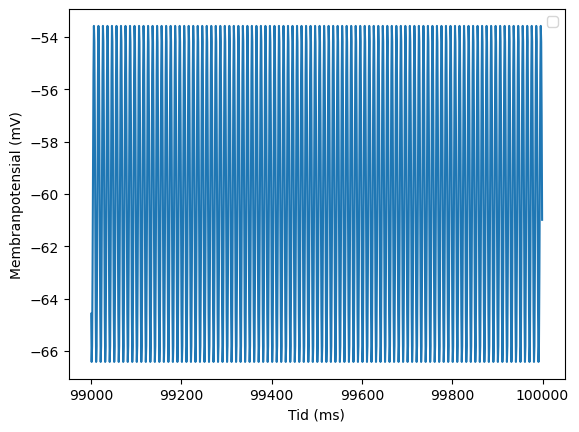

Max endring i membranpotensial: 6.418759650375094
Simulert Vm amplitude: 6.4188 mV


In [14]:
"""Nå skal denne funksjonen gi samme membranpotensial-endring"""
find_V_from_I(sim_time=100000, noisy=False, tau_m=10,
                 second_sine=False,
                 a=407, sd=0, f=100,
                 E_m=-60, V_th=300, bin_size=1, seed=42)

In [9]:
find_input_amplitude(f=1000, tau_m=10, V_target=0.007, R_si=100e6)

NameError: name 'find_input_amplitude' is not defined

=1.04 mikro-ampere ved 2012 Hz

Transfer-funksjonen angir lineært forhold mellom Vm-amplitude og I_amp. 
Når frekvensen blir stor så kan vi ikke bruke dette forholdet. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


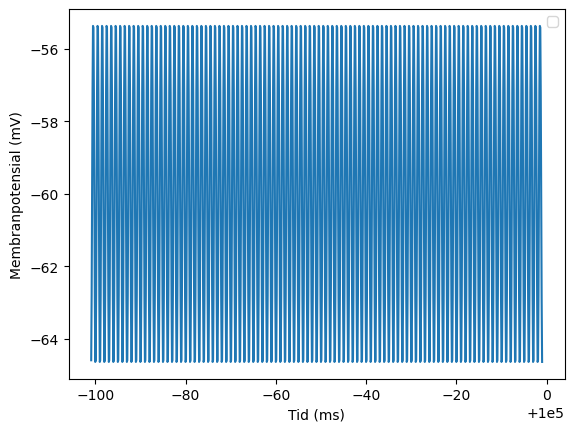

Max endring i membranpotensial: 4.638470689608823
Simulert Vm amplitude: 4.6385 mV


In [7]:
"""usikker på om jeg må bruke verdien fra denne, a=3000pA (det som injiseres i A)"""
find_V_from_I(sim_time=100000, noisy=False, tau_m=10, 
                 second_sine=False, beat=20,
                 a=3000, sd=0, f=1000, 
                 E_m=-60, V_th=1e6, bin_size=0.25, seed=42)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



May 04 18:43:35 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.


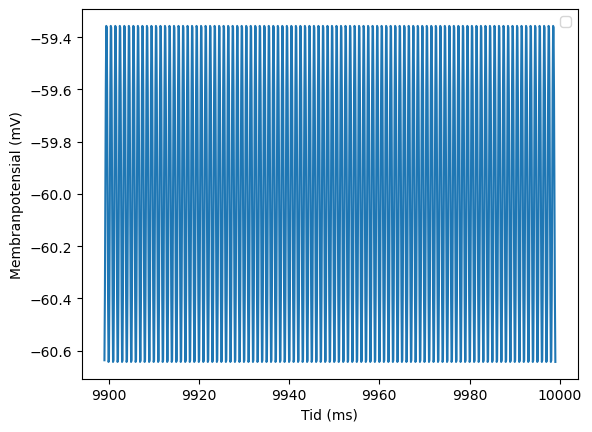

Max endring i membranpotensial: 0.6432012689590891
Simulert Vm amplitude: 0.6432 mV


In [4]:
"""eller denne: I_amp = 416pA"""
find_V_from_I(sim_time=10000, noisy=False, tau_m=10, 
                 second_sine=False, beat=20,
                 a=416, sd=0, f=1000,
                 E_m=-60, V_th=1e6, bin_size=0.2, seed=42)

## Membranpotensial som funksjon av frekvens V(f)

In [38]:
def V_vs_f(sim_time=100000, noisy=False, 
                  second_sine=False,tau_m=10,
                 a_values=[10,100], sd=0, f_values=np.linspace(10,1000,10),
                E_m=-60, V_th=0, bin_size=1, seed=np.random.randint(0,1e+6), log=False):
    
    figs, axs = plt.subplots(len(a_values), figsize=(5,5))
    
    for i,a in enumerate(a_values):
        Vm_max = []
        for j,f in enumerate(f_values):
            results = build_simulation(sim_time=sim_time, noisy=noisy, second_sine=second_sine, tau_m=tau_m,
                                        f1=f, a1=a, SD=sd, seed=seed, V_thresh=V_th, resolution=0.1)  
       
            
            spike_times = results["spike_times"]
            Vm = results["Vm"][1000:]
            V_th = results["V_th"]
            sim_time = results["sim_time"]
            times = results["times"]
            Vm_max.append((np.max(Vm+60)))
        
        # Theoretical membrane potential 
        V_theoretical =  a*1e-12*100e6 / np.sqrt(1 + (2 * np.pi * f_values * tau_m*1e-3) ** 2) /1e-3
            
    
        
        axs[i].plot(f_values, V_theoretical, label="theoretical", color="#006D5B")
        axs[i].plot(f_values, Vm_max, linestyle="--", dashes=(2,5), label=f"a={a}", color="#A3D4CC")
        axs[i].set_xlabel("f [Hz]")
        axs[i].set_ylabel("Vm [mV]")
        axs[i].set_title("Membrane potential vs. frequency", fontsize=12, color="#006D5B")
        if log:
            axs[i].set_xscale("log")
            axs[i].set_yscale("log")
        axs[i].legend()
        
        axs[i].set_facecolor("#F5F5F5")
        axs[i].spines["top"].set_visible(False)
        axs[i].spines["right"].set_visible(False)
        axs[i].spines["left"].set_color("#333333")
        axs[i].spines["bottom"].set_color("#333333")
        axs[i].xaxis.label.set_color("#006D5B")
        axs[i].yaxis.label.set_color("#006D5B")
        axs[i].tick_params(axis='both', colors="#333333")
        axs[i].grid(color='#A3D4CC', linestyle="-", linewidth=0.5)
        axs[i].legend(facecolor="white", framealpha=1, edgecolor="#333333")
        
    plt.tight_layout()
    plt.show()

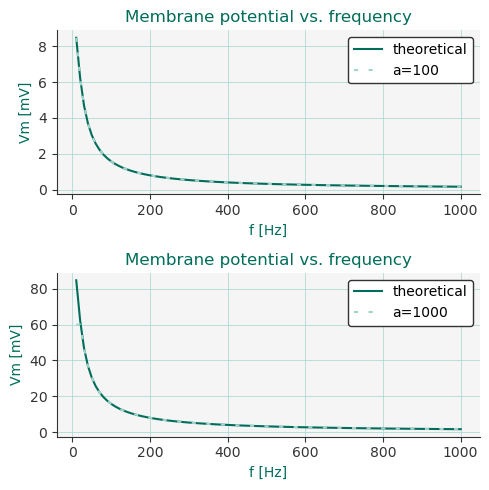

In [39]:
V_vs_f(sim_time=100000, noisy=False, 
                  second_sine=False,tau_m=10,
                 a_values=[100,1000], sd=0, f_values=np.linspace(10,1000,100),
                E_m=-60, V_th=0, bin_size=0.2, seed=np.random.randint(0,1e+6))

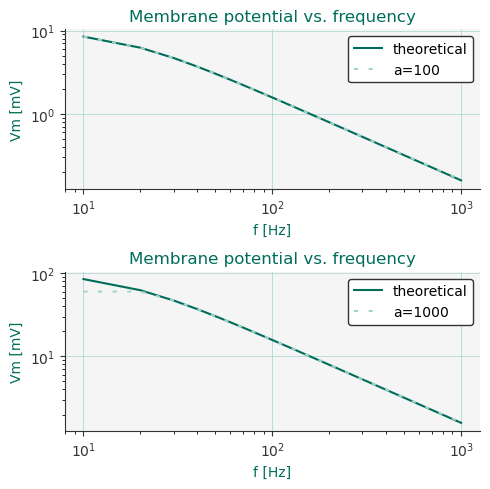

In [40]:
V_vs_f(sim_time=100000, noisy=False, 
                  second_sine=False,tau_m=10,
                 a_values=[100,1000], sd=0, f_values=np.linspace(10,1000,100),
                E_m=-60, V_th=0, bin_size=0.2, seed=np.random.randint(0,1e+6), log=True)

In [21]:
def check_one_frequency(sim_time=10000, noisy=False, 
                  second_sine=False,tau_m=10,
                 a_values=[10,100], sd=0, f=12,
                E_m=-60, V_th=0, seed=np.random.randint(0,1e+6)):
    
    figs, axs = plt.subplots(len(a_values), figsize=(5,5))
    
    for i,a in enumerate(a_values):
        
        results = build_network(sim_time=sim_time, noisy=noisy, second_sine=second_sine, tau_m=tau_m,
                                    f1=f, a1=a, SD=sd, seed=seed, V_thresh=V_th)  
    
        
        spike_times = results["spike_times"]
        Vm = results["Vm"][-1000:]
        V_th = results["V_th"]
        sim_time = results["sim_time"]
        times = results["times"][-1000:]
        
        
        # Theoretical membrane potential 
        V_theoretical = E_m + a*1e-12*100e6 / np.sqrt(1 + (2 * np.pi * f * tau_m*1e-3) ** 2) /1e-3
    
        axs[i].plot(times/10**2, Vm, label=f"a={a}")
        axs[i].plot(times/10**2, np.ones(len(times))*(V_theoretical), label="theoretical")
        axs[i].set_xlabel("time (s)")
        axs[i].set_ylabel("Membrane potential (mV)")
        #axs[i].set_xscale("log")
        #axs[i].set_yscale("log")
        axs[i].legend()
    plt.tight_layout()
    plt.show()
    

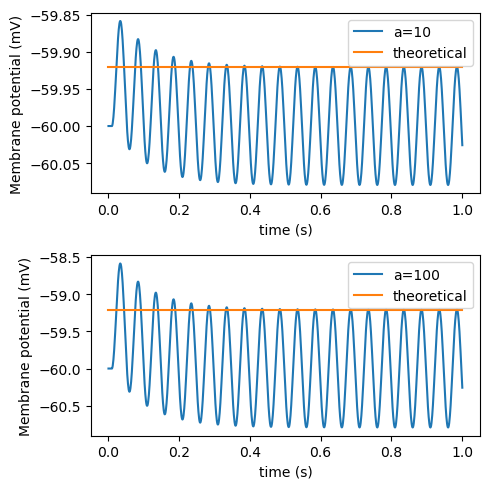

In [23]:
check_one_frequency(f=200)

In [39]:
def V_vs_I(sim_time=10000, noisy=False, 
                  second_sine=False,tau_m=10,
                 a_values=np.linspace(10,100,5), sd=179, f_values=12,
                E_m=-60, V_th=0, seed=np.random.randint(0,1e+6)):
    
    figs, axs = plt.subplots(len(f_values), figsize=(5,20))
    
    for i,f in enumerate(f_values):
        Vm_max = []
        H = []
        for j,a in enumerate(a_values):
            results = build_network(sim_time=sim_time, noisy=noisy, second_sine=second_sine, tau_m=tau_m,
                                        f1=f, a1=a, a2=a, SD=sd, seed=seed, V_thresh=V_th)  
       
            
            spike_times = results["spike_times"]
            Vm = results["Vm"]
            V_th = results["V_th"]
            sim_time = results["sim_time"]
            times = results["times"][-1000:]
            Vm_max.append(np.max(Vm))
        C_m = 100*(1e-12)
        R = tau_m / C_m
        V_theoretical = -60+a_values*1e-12*100e6 / np.sqrt(1 + (2 * np.pi * f * tau_m*1e-3) ** 2) /1e-3
        
        axs[i].plot(a_values,Vm_max, label=f"f={f}")
        axs[i].plot(a_values, V_theoretical[-1000:], label="theoretical")
        axs[i].set_xlabel("I_amp (pA)")
        axs[i].set_ylabel("Membrane potential (mV)")
        axs[i].legend()
    plt.tight_layout()
    plt.show()

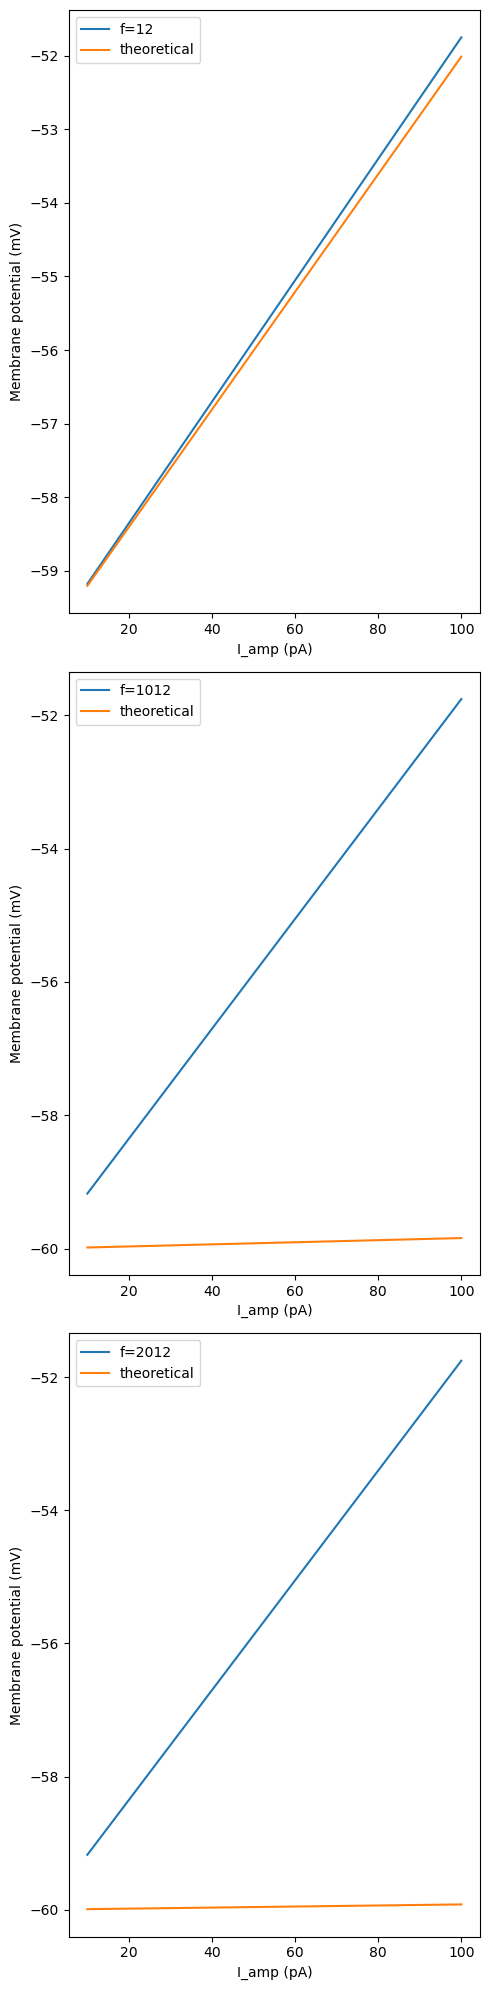

In [40]:
V_vs_I(sim_time=10000, noisy=False, 
                  second_sine=False,tau_m=10,
                 a_values=np.linspace(10,100,10), sd=179, f_values=[12,1012,2012],
                E_m=-60, V_th=0, seed=np.random.randint(0,1e+6))